# HyperParameters Optimization, 3 steps Neural Network

100%|██████████| 15/15 [47:28<00:00, 189.92s/trial, best loss: 0.06849283219253101]
{'kernel_init': 'uniform', 'l2weight': 0.31156203672279537, 'lr': 0.0013730437747550028, 'nodes': 20.0, 'opt': 'Adamax'}


In [25]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from keras.utils import custom_object_scope
from keras.initializers import glorot_uniform
from keras.models import save_model#, load_model
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions import getModel, kCrossVal, transfBestparam, import_data, normalization
from time import perf_counter
import pandas
import keras
import tensorflow as tf

In [26]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data preparation

In [27]:
NepoLF = 5000  # number of epochs for first NN: NN_LF
NepoLin = 1500  # number of epochs for second NN: NN_Lin
NepoHF = 3000  # number of epochs for second NN: NN_HF
Nlf = 30
Nhf = 25

########################     PREPARATION      ##########################
# introduction of the data
file_path_LF = "../DATA/reaction_diffusion_LF_46_d75.mat"
(reaction_LF_test, U_LF_test) = import_data(file_path_LF)
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)


In [28]:
reaction_LF_test =normalization(reaction_LF_test)
reaction_HF_test = normalization(reaction_HF_test)
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]


In [29]:


U_LF_test = U_LF_test[
    :,
    - 1,
    12,   # <--
    12,   # <--
]
U_HF_test = U_HF_test[
    :, -1, 44,44
]

U_LF_test = normalization(U_LF_test)
U_HF_test = normalization(U_HF_test)

permutation = np.random.permutation(len(reaction_LF_test))
reaction_LF = reaction_LF_test[permutation][0:Nlf]
U_LF = U_LF_test[permutation][0:Nlf]

permutation = np.random.permutation(len(reaction_HF_test))
reaction_HF = reaction_HF_test[permutation][0:Nhf]
U_HF = U_HF_test[permutation][0:Nhf]


# Neural Network
## Low Fidelity NN 

In [30]:
##########################       FIRST NN: NN_LF     ##########################

K.clear_session()
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
}  # where do they come from

modelLF = getModel(bestLF_params, "LF")
histLF = modelLF.fit(
    reaction_LF, U_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
)
print("LF NN done")

ULF = modelLF.predict(reaction_LF_test)
print("\nLF Model:")

test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
print(f"Test MSE: {test_mse}")

r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
    np.square(U_LF_test - np.mean(U_LF_test))
)
print(f"R^2: {r_2}")

LF NN done
2/2 [==============================] - 0s 17ms/step

LF Model:
Test MSE: 0.3460518328546827
R^2: -1.8113087230473215


2/2 [==============================] - 0s 3ms/step


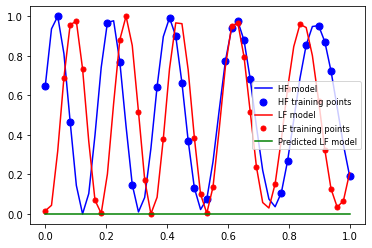

In [31]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
plt.plot(reaction_HF_test[:,0], U_HF_test, "b-", linewidth=1.5, label="HF model")
plt.plot(
    reaction_HF[:,0],
    U_HF,
    "bo",
    markersize=7,
    label="HF training points",
)
plt.plot(reaction_LF_test[:,0], U_LF_test, "r-", linewidth=1.5, label="LF model")
plt.plot(
    reaction_LF[:,0],
    U_LF,
    "ro",
    markersize=5,
    label="LF training points",
)
plt.plot(
    reaction_LF_test[:,0],
    modelLF.predict(reaction_LF_test),
    "g-",
    label="Predicted LF model",
)
plt.legend(prop={"size": 8.3})
plt.show()


In [32]:
print(f"\n-------  #HF data = {Nhf}  -------")
start = perf_counter()

##########################    SECOND NN: NN_Lin    ##########################
reaction_test_help = modelLF.predict(reaction_LF_test)[:, 0]
reaction_test_in = np.concatenate(
            (reaction_LF_test, reaction_test_help.reshape(-1,1)),axis=1
        )
reaction_train_help = modelLF.predict(reaction_HF)[:, 0]  # f_LF(mu_hf_train)
reaction_lin=np.concatenate(
            (reaction_HF, reaction_train_help.reshape(-1,1)),axis=1
        )


bestLin_params = {
    "lr": 0.001,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
    "l2weight": 0.01,
}
modelLin = getModel(bestLin_params, "Hflin")
histLin = modelLin.fit(
    reaction_lin,
    U_HF,
    validation_data=(reaction_test_in, U_HF_test),
    epochs=NepoLin,
    batch_size=Nhf,
    verbose=0,
    validation_freq=50,
)

ULin = modelLin.predict(
    np.concatenate(
            (reaction_LF_test, reaction_test_help.reshape(-1,1)),axis=1
        )
)



-------  #HF data = 25  -------
2/2 [==============================] - 0s 4ms/step


2/2 [==============================] - 0s 0s/step


In [33]:
##########################    THIRD NN: NN_HF    ##########################
# Input for training NN_HF
reaction_help1 = modelLin.predict(reaction_lin)[:, 0]
reaction_final =np.concatenate(
            (reaction_HF, reaction_train_help.reshape(-1,1), reaction_help1.reshape(-1,1)),axis=1
        )

# Input for testing NN_HF
reaction_test_help1 = modelLin.predict(reaction_test_in)[:, 0]
reaction_test_final = np.concatenate(
            (reaction_HF_test, reaction_test_help.reshape(-1,1), reaction_test_help1.reshape(-1,1)),axis=1
        )

name = "3step"

2/2 [==============================] - 0s 0s/step


In [34]:
####################    HYPERPARAMETER OPTIMIZATION    #######################
MAX_EVAL = 15

K.clear_session()
bayes_trials = Trials()
opt_list = ["Adam", "Adamax"]
kernel_list = ["uniform", "glorot_uniform"]
aux_dic = {"opt": opt_list, "kernel_init": kernel_list}
space = {
    "nodes": hp.qloguniform("nodes", np.log(4), np.log(64), 2),
    "l2weight": hp.loguniform("l2weight", np.log(0.0001), np.log(1)),
    "lr": hp.loguniform("lr", np.log(0.0001), np.log(0.1)),
    "kernel_init": hp.choice("kernel_init", kernel_list),
    "opt": hp.choice("opt", opt_list),
}


def objective(params):
    K.clear_session()
    CVres = kCrossVal(Nhf, NepoHF, reaction_final, U_HF, params, name)
    return {"loss": CVres, "params": params, "status": STATUS_OK}


# The following call will optimize and select the best parameters:
best_params = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=MAX_EVAL,
    trials=bayes_trials,
)

transfBestparam(best_params, aux_dic)
print(best_params)


1/1 [==============================] - 0s 66ms/step  

1/1 [==============================] - 0s 35ms/step  

1/1 [==============================] - 0s 34ms/step  

1/1 [==============================] - 0s 17ms/step  

1/1 [==============================] - 0s 33ms/step  

1/1 [==============================] - 0s 15ms/step  

1/1 [==============================] - 0s 33ms/step  

1/1 [==============================] - 0s 17ms/step  

1/1 [==============================] - 0s 34ms/step  

1/1 [==============================] - 0s 12ms/step  

1/1 [==============================] - 0s 17ms/step  

1/1 [==============================] - 0s 22ms/step  

1/1 [==============================] - 0s 33ms/step  

1/1 [==============================] - 0s 31ms/step  

1/1 [==============================] - 0s 37ms/step  

1/1 [==============================] - 0s 33ms/step  

1/1 [==============================] - 0s 38ms/step  

1/1 [==============================] - 0s 34ms/step  

1/1 [=====

In [35]:
####################    NN_HF training and PREDICTION    #######################
finalModel = getModel(best_params, name)
hist = finalModel.fit(
    reaction_final,
    U_HF,
    validation_data=(reaction_test_final, U_HF_test),
    epochs=NepoHF,
    batch_size=Nhf,
    verbose=0,
    validation_freq=20,
)

UHF = finalModel.predict(reaction_test_final)

stop = perf_counter()
elapsed = stop - start
print("Elapsed time: ", elapsed)
print("\nHF Model:")

test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
print(f"Test MSE: {test_mse}")

r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
    np.square(U_HF_test - np.mean(U_HF_test))
)
print(f"R^2: {r2_HF}")

# print("Number of base functions: ", int(Nlf_models[m]))
# print("Number of HF data: ", n_HF)
############################################################
U_Lin = modelLin.predict(
    np.concatenate(
            (reaction_LF_test, reaction_test_help.reshape(-1,1)),axis=1
        )
)


2/2 [==============================] - 0s 0s/step
Elapsed time:  5066.962563099805

HF Model:
Test MSE: 0.1254433361026926
R^2: -0.10816855403370096
2/2 [==============================] - 0s 0s/step


2/2 [==============================] - 0s 17ms/step


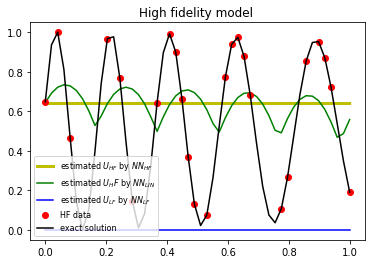

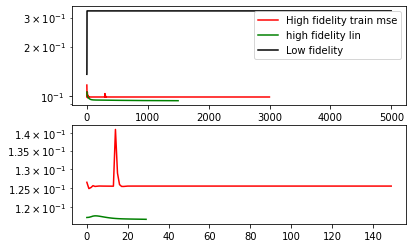

In [36]:
####################    HF GRAPHS    #######################
plt.figure()
plt.plot(
    reaction_HF_test[:,0],
    UHF,
    "y-",
    label="estimated $U_{HF}$ by $NN_{HF}$",
    linewidth=3,
)
plt.plot(reaction_HF_test[:,0], U_Lin, "g-", label="estimated $U_HF$ by $NN_{LIN}$")
plt.plot(
    reaction_HF_test[:,0],
    modelLF.predict(reaction_HF_test),
    "b-",
    label="estimated $U_{LF}$ by $NN_{LF}$",
)
plt.plot(reaction_HF[:,0], U_HF, "ro", label="HF data")
plt.plot(reaction_HF_test[:,0], U_HF_test, "k-", label="exact solution")
plt.title("High fidelity model ")
plt.legend(prop={"size": 8})

####################    TRAINING INSIGHTS    #######################
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(hist.history["mse"], color="red", label="High fidelity train mse")
plt.plot(histLin.history["mse"], color="green", label="high fidelity lin")
plt.plot(histLF.history["mse"], color="black", label="Low fidelity")
plt.legend()
plt.yscale("log")
plt.subplot(2, 1, 2)
plt.plot(hist.history["val_mse"], color="red")
plt.plot(histLin.history["val_mse"], color="green")
plt.yscale("log")
